In [15]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import random_statevector, Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector, plot_histogram

Initial state |ψ> to be teleported:


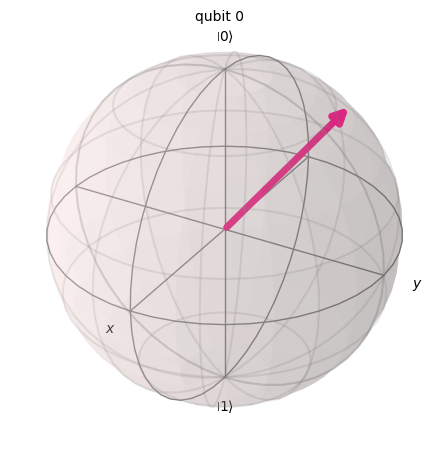

In [16]:
# Let's create a random quantum state to teleport.
psi = random_statevector(2)
print("Initial state |ψ> to be teleported:")
display(plot_bloch_multivector(psi))

In [17]:
# Define the registers
qr = QuantumRegister(3, name="q")
crz = ClassicalRegister(1, name="crz")
crx = ClassicalRegister(1, name="crx")
qc = QuantumCircuit(qr, crz, crx)

# Initialize Alice's message qubit (q0) with the state |ψ>
qc.initialize(psi, 0)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

Circuit after creating Bell pair:


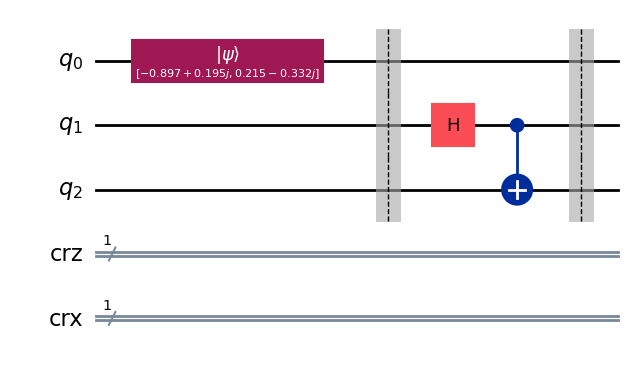

In [18]:
# Alice and Bob create a shared entangled pair (q1 and q2)
qc.h(1)
qc.cx(1, 2)
qc.barrier()
print("Circuit after creating Bell pair:")
qc.draw('mpl')


Circuit after Alice's operations:


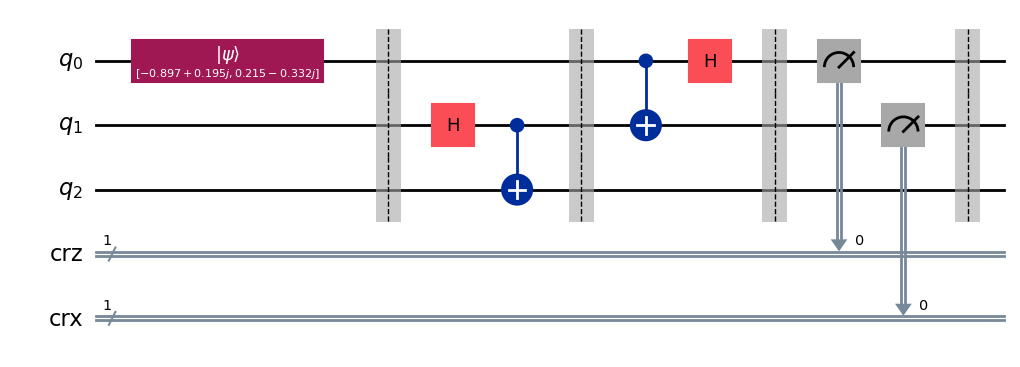

In [19]:
# Alice entangles her message qubit with her half of the pair
qc.cx(0, 1)
qc.h(0)
qc.barrier()

# Alice measures her two qubits
qc.measure(0, crz)
qc.measure(1, crx)
qc.barrier()
print("\nCircuit after Alice's operations:")
qc.draw('mpl')


Full Teleportation Circuit:


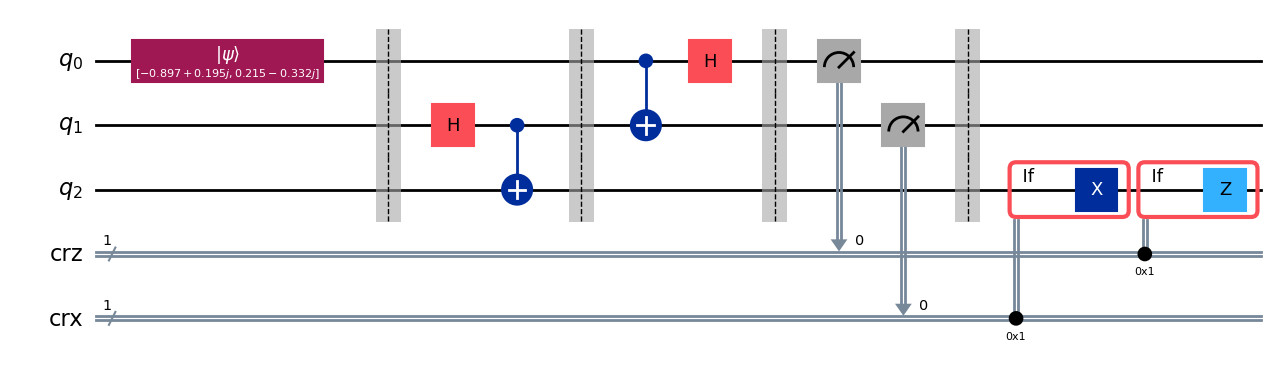

In [20]:
# Bob applies gates to his qubit based on the classical bits he receives from Alice
with qc.if_test((crx, 1)):
    qc.x(2)
with qc.if_test((crz, 1)):
    qc.z(2)

print("\nFull Teleportation Circuit:")
qc.draw('mpl')


Final state of Bob's qubit (q2):


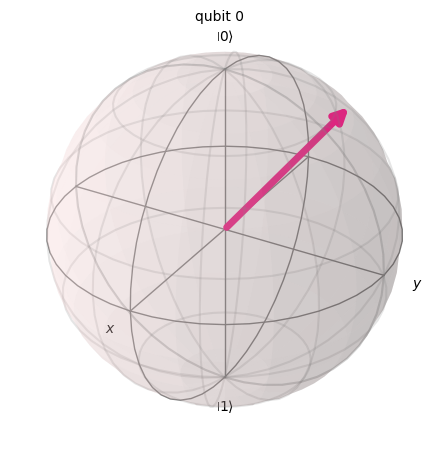

In [21]:
# We use the statevector simulator to see the final state of all qubits
backend = AerSimulator()
qc_state = qc.copy()
qc_state.save_statevector() 
result = backend.run(qc_state).result()
final_vector = result.get_statevector()

print("\nFinal state of Bob's qubit (q2):")
# We extract the state of Bob's qubit (q2) from the full 3-qubit statevector.
# The Statevector constructor automatically normalizes the input data.
bob_vector = Statevector([final_vector.data[0], final_vector.data[4]]) # <-- This is the only line needed

display(plot_bloch_multivector(bob_vector))

In [22]:
print("Are the initial and final states equivalent?")
print(psi.equiv(bob_vector))

Are the initial and final states equivalent?
True
